# NIH Chest X-ray - Data Preprocessing

This notebook prepares the NIH Chest X-ray dataset for multi-label classification experiments. The resulting DataLoaders are used in subsequent notebooks for: model training, evaluation, and explainability analysis.

## Contents:
1. Dataset configuration and path setup
2. Metadata loading and cleaning
3. Multi-label encoding
4. Patient-aware train/validation/test splitting
5. Image preprocessing and augmentation
6. PyTorch Dataset and DataLoader creation
7. Data pipeline verification and visualization

## 1. Dataset configuration and path setup

This section defines the dataset root directory, file paths, class labels, and key hyperparameters such as image size, batch size, and normalization values. It ensures a consistent configuration for all subsequent preprocessing steps.

In [21]:
# Standard library
import os
from pathlib import Path
import random

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader

# Torchvision
from torchvision import transforms

# Dataset splitting
from sklearn.model_selection import train_test_split, GroupShuffleSplit

# Notebook settings
plt.style.use("default")
pd.set_option("display.max_columns", 50)

print("Imports successful.")

Imports successful.


In [22]:
# Random seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Seed set to {SEED}")

Seed set to 42


In [23]:
# =============================================================================
# Dataset Paths
# =============================================================================

DATASET_ROOT = Path("/Volumes/pm961/archive-chest-xrays-nih")

DATA_ENTRY_CSV = DATASET_ROOT / "Data_Entry_2017.csv"

TRAIN_VAL_LIST = DATASET_ROOT / "train_val_list.txt"
TEST_LIST = DATASET_ROOT / "test_list.txt"

# NIH image folders
IMAGE_DIRS = [
    DATASET_ROOT / f"images_{i:03d}" / "images"
    for i in range(1, 13)
]

# =============================================================================
# Dataset Parameters
# =============================================================================

CLASS_NAMES = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax",
    "No Finding",
]

NUM_CLASSES = len(CLASS_NAMES)

# Quick experimentation subset
SUBSET_SIZE = 1000

# Validation split ratio
VAL_SPLIT = 0.1

# Image size
IMAGE_SIZE = 224
# ImageNet normalization (pretrained models expect this)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Batch size
BATCH_SIZE = 32

# DataLoader workers
NUM_WORKERS = 4

print(f"Number of classes: {NUM_CLASSES}")
print(f"Subset size: {SUBSET_SIZE}")

Number of classes: 15
Subset size: 1000


In [24]:
print("Dataset root exists:", DATASET_ROOT.exists())
print("Metadata CSV exists:", DATA_ENTRY_CSV.exists())

for path in IMAGE_DIRS[:3]:
    print(path, "->", path.exists())

Dataset root exists: True
Metadata CSV exists: True
/Volumes/pm961/archive-chest-xrays-nih/images_001/images -> True
/Volumes/pm961/archive-chest-xrays-nih/images_002/images -> True
/Volumes/pm961/archive-chest-xrays-nih/images_003/images -> True


## 2. Metadata loading and cleaning

This section loads the metadata file, maps each image to its corresponding file path, and removes entries with missing or invalid image references to ensure dataset integrity.

In [25]:
df = pd.read_csv(DATA_ENTRY_CSV)

print(df.shape)
df.head()

(112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [26]:
image_index = {}

for img_dir in IMAGE_DIRS:
    if img_dir.exists():
        for p in img_dir.iterdir():
            if p.suffix == ".png":
                image_index[p.name] = p

print("Indexed images:", len(image_index))

Indexed images: 224240


In [27]:
df["filepath"] = df["Image Index"].map(image_index)

missing = df["filepath"].isna().sum()
print("Missing images:", missing)

df = df.dropna(subset=["filepath"]).reset_index(drop=True)

df.head()

Missing images: 0


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,filepath
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,/Volumes/pm961/archive-chest-xrays-nih/images_...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,/Volumes/pm961/archive-chest-xrays-nih/images_...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,/Volumes/pm961/archive-chest-xrays-nih/images_...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,/Volumes/pm961/archive-chest-xrays-nih/images_...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,/Volumes/pm961/archive-chest-xrays-nih/images_...


## 3. Multi-label encoding

This section transforms textual disease annotations into a multi-hot encoded vector representation, enabling the dataset to be used for multi-label classification tasks.

In [28]:
class_names = CLASS_NAMES
class_to_idx = {c: i for i, c in enumerate(class_names)}

def encode_labels(label_str):
    vec = np.zeros(len(class_names), dtype=np.float32)
    for l in label_str.split("|"):
        l = l.strip()
        if l in class_to_idx:
            vec[class_to_idx[l]] = 1.0
    return vec

df["labels"] = df["Finding Labels"]
df["label_vector"] = df["labels"].apply(encode_labels)

df[["Finding Labels", "label_vector"]].head()

,Finding Labels,label_vector
0,Cardiomegaly,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,Cardiomegaly|Emphysema,"[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
2,Cardiomegaly|Effusion,"[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
3,No Finding,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Hernia,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."


## 4. Patient-aware train/validation/test splitting

This section splits the dataset into training, validation, and test sets using patient-level grouping to prevent data leakage (to ensure that images from the same patient do not appear in multiple splits).

In [29]:
if "Patient ID" in df.columns:
    df["Patient ID"] = df["Patient ID"].astype(str)

df[["Image Index", "Patient ID"]].head()

,Image Index,Patient ID
0,00000001_000.png,1
1,00000001_001.png,1
2,00000001_002.png,1
3,00000002_000.png,2
4,00000003_000.png,3


In [47]:
train_val_files = set(Path(TRAIN_VAL_LIST).read_text().splitlines())
test_files = set(Path(TEST_LIST).read_text().splitlines())

train_val_df = df[df["Image Index"].isin(train_val_files)].reset_index(drop=True)
test_df = df[df["Image Index"].isin(test_files)].reset_index(drop=True)

print(len(train_val_df), len(test_df))
train_df.to_csv("outputs/train_df.csv", index=False)
val_df.to_csv("outputs/val_df.csv", index=False)
test_df.to_csv("outputs/test_df.csv", index=False)

86524 25596


In [31]:
group_col = "Patient ID" if "Patient ID" in df.columns else None

if group_col:
    splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=SEED)
    train_idx, val_idx = next(splitter.split(train_val_df, groups=train_val_df[group_col]))

    train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
    val_df = train_val_df.iloc[val_idx].reset_index(drop=True)
else:
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=VAL_SPLIT,
        random_state=SEED
    )

print(len(train_df), len(val_df), len(test_df))

77353 9171 25596


## 5. Image preprocessing and augmentation

This section defines image transformations for training and evaluation, including resizing, normalization, and data augmentation techniques to improve model generalization.

In [32]:
train_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(degrees=7, translate=(0.02, 0.02), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

## 6. PyTorch Dataset and DataLoader creation

This section implements a custom PyTorch Dataset class and constructs DataLoaders for efficient batch loading, shuffling, and parallel data processing during model training and evaluation.

In [33]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.labels = np.stack(df["label_vector"].values)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["filepath"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        return {
            "image": img,
            "label": label,
            "filename": row["Image Index"]
        }

In [43]:
train_ds = ChestXrayDataset(train_df, transform=train_tfms)
val_ds = ChestXrayDataset(val_df, transform=val_tfms)
test_ds = ChestXrayDataset(test_df, transform=val_tfms)

In [38]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Train batches:", len(train_loader))

Train batches: 2418


In [39]:
batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["label"].shape)
print(batch["filename"][:5])

torch.Size([32, 3, 224, 224])
torch.Size([32, 15])
['00014452_011.png', '00000636_000.png', '00007548_001.png', '00030247_000.png', '00009567_002.png']


## 7. Data pipeline verification and visualization

This section validates the complete data pipeline by inspecting batch shapes and visualizing sample images to ensure correct preprocessing, label alignment, and overall dataset readiness for training.

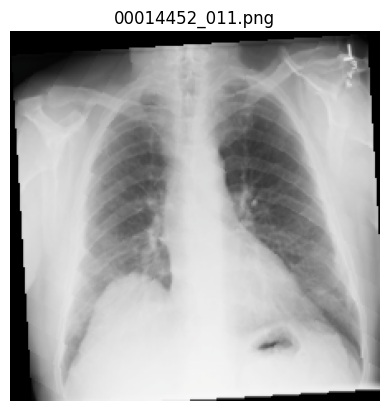

In [40]:
import matplotlib.pyplot as plt

img = batch["image"][0].permute(1, 2, 0).numpy()

# undo normalization for display (approx)
img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
img = np.clip(img, 0, 1)

plt.imshow(img)
plt.title(batch["filename"][0])
plt.axis("off")
plt.show()